# Phase 1: Anomaly Detection Model Training & Evaluation
---
**Based on Phase 0 findings:**
- Context-aware Z-score is the strongest signal (203 unique anomalies found)
- Isolation Forest works well with temporal features
- Rolling Z-score found nothing useful — dropped
- Only 18 points had 2+ method agreement — thresholds need tuning
- COVID-2020 is a structural shift, not an anomaly

**Pipeline:**
1. Feature engineering (temporal + lag + rolling stats)
2. Context-Aware Statistical Detector
3. Isolation Forest (tuned)
4. Ensemble Scoring with calibrated thresholds
5. Synthetic anomaly injection for validation
6. Anomaly classification (spike/drop/shift)
7. Final evaluation & visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_excel('/kaggle/input/datasets/atromixtheanalyzer/energy-consumption-dataset/Energy Consumption Dataset.xlsx')
df.columns = ['start', 'end', 'consumption']
df = df.sort_values('start').reset_index(drop=True)
df['start'] = pd.to_datetime(df['start'])
print(f"Loaded: {df.shape[0]} rows, {df['start'].min()} to {df['start'].max()}")

Loaded: 52966 rows, 2015-12-31 21:00:00 to 2021-12-31 20:00:00


## 1. Feature Engineering

In [2]:
# Temporal features
df['hour'] = df['start'].dt.hour
df['dow'] = df['start'].dt.dayofweek
df['month'] = df['start'].dt.month
df['year'] = df['start'].dt.year
df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)
df['day_of_year'] = df['start'].dt.dayofyear

# Cyclical encoding (so hour 23 is close to hour 0)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Lag features
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:  # 168 = 1 week
    df[f'lag_{lag}'] = df['consumption'].shift(lag)

# Rolling statistics
for window in [6, 12, 24, 48, 168]:
    df[f'rolling_mean_{window}'] = df['consumption'].rolling(window, center=False).mean()
    df[f'rolling_std_{window}'] = df['consumption'].rolling(window, center=False).std()

# Diff features
df['diff_1'] = df['consumption'].diff(1)
df['diff_24'] = df['consumption'].diff(24)  # same hour yesterday

# Ratio to rolling mean
df['ratio_to_24h'] = df['consumption'] / df['rolling_mean_24']
df['ratio_to_168h'] = df['consumption'] / df['rolling_mean_168']

# Drop rows with NaN from lag/rolling
df_clean = df.dropna().reset_index(drop=True)
print(f"After feature engineering: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"Features: {list(df_clean.columns)}")

After feature engineering: 52798 rows, 37 columns
Features: ['start', 'end', 'consumption', 'hour', 'dow', 'month', 'year', 'is_weekend', 'day_of_year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_48', 'rolling_std_48', 'rolling_mean_168', 'rolling_std_168', 'diff_1', 'diff_24', 'ratio_to_24h', 'ratio_to_168h']


## 2. Context-Aware Statistical Detector
The star from Phase 0. We compute Z-scores within context groups (hour x weekend x month).

In [3]:
def context_aware_zscore(data, group_cols=['hour', 'is_weekend', 'month'], col='consumption'):
    """Compute Z-scores within context groups."""
    result = data.copy()
    group_stats = data.groupby(group_cols)[col].agg(['mean', 'std']).reset_index()
    group_stats.columns = group_cols + ['ctx_mean', 'ctx_std']
    result = result.merge(group_stats, on=group_cols, how='left')
    result['ctx_zscore'] = (result[col] - result['ctx_mean']) / result['ctx_std']
    result['ctx_zscore_abs'] = result['ctx_zscore'].abs()
    return result

df_clean = context_aware_zscore(df_clean)

# Analyze threshold sensitivity
print("=== Context-Aware Z-Score Threshold Analysis ===")
for t in [2.0, 2.5, 3.0, 3.5]:
    n = (df_clean['ctx_zscore_abs'] > t).sum()
    pct = 100 * n / len(df_clean)
    print(f"  |Z| > {t}: {n:5d} anomalies ({pct:.2f}%)")

# Use 2.5 as threshold (more practical than 3.0 from Phase 0)
ctx_threshold = 2.5
df_clean['anom_ctx'] = (df_clean['ctx_zscore_abs'] > ctx_threshold).astype(int)
print(f"\nUsing threshold {ctx_threshold}: {df_clean['anom_ctx'].sum()} anomalies")

=== Context-Aware Z-Score Threshold Analysis ===
  |Z| > 2.0:  2452 anomalies (4.64%)
  |Z| > 2.5:   697 anomalies (1.32%)
  |Z| > 3.0:   194 anomalies (0.37%)
  |Z| > 3.5:    25 anomalies (0.05%)

Using threshold 2.5: 697 anomalies


## 3. Isolation Forest (Tuned)

In [4]:
feature_cols = [
    'consumption', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'month_sin', 'month_cos', 'is_weekend',
    'lag_1', 'lag_24', 'lag_168',
    'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_168', 'rolling_std_168',
    'diff_1', 'diff_24',
    'ratio_to_24h', 'ratio_to_168h'
]

X = df_clean[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test multiple contamination rates
print("=== Isolation Forest Contamination Sweep ===")
results = {}
for cont in [0.005, 0.01, 0.015, 0.02, 0.03]:
    model = IsolationForest(
        n_estimators=200,
        contamination=cont,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )
    preds = model.fit_predict(X_scaled)
    scores = model.decision_function(X_scaled)
    n_anom = (preds == -1).sum()
    print(f"  contamination={cont}: {n_anom} anomalies ({100*n_anom/len(df_clean):.2f}%)")
    results[cont] = {'preds': preds, 'scores': scores, 'n_anom': n_anom}

# Use 1.5% — between the too-conservative 1% and too-loose 2%
iso_cont = 0.015
iso_model = IsolationForest(
    n_estimators=200,
    contamination=iso_cont,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
df_clean['iso_pred'] = iso_model.fit_predict(X_scaled)
df_clean['iso_score'] = iso_model.decision_function(X_scaled)
df_clean['anom_iso'] = (df_clean['iso_pred'] == -1).astype(int)

print(f"\nFinal IF model (cont={iso_cont}): {df_clean['anom_iso'].sum()} anomalies")

=== Isolation Forest Contamination Sweep ===
  contamination=0.005: 264 anomalies (0.50%)
  contamination=0.01: 528 anomalies (1.00%)
  contamination=0.015: 792 anomalies (1.50%)
  contamination=0.02: 1056 anomalies (2.00%)
  contamination=0.03: 1584 anomalies (3.00%)

Final IF model (cont=0.015): 792 anomalies


## 4. Ensemble Scoring
Combine Context-Aware Z-Score + Isolation Forest. An anomaly is flagged if **either** method detects it, with a confidence score.

In [5]:
# Normalize scores to [0, 1] range
from sklearn.preprocessing import MinMaxScaler

# Context Z-score: higher abs = more anomalous
ctx_scores = df_clean['ctx_zscore_abs'].values.reshape(-1, 1)
ctx_norm = MinMaxScaler().fit_transform(ctx_scores).flatten()

# ISO score: lower (more negative) = more anomalous, flip it
iso_scores = -df_clean['iso_score'].values.reshape(-1, 1)  # negate so higher = more anomalous
iso_norm = MinMaxScaler().fit_transform(iso_scores).flatten()

df_clean['score_ctx_norm'] = ctx_norm
df_clean['score_iso_norm'] = iso_norm

# Weighted ensemble: context-aware gets more weight (it was more discriminative in Phase 0)
w_ctx, w_iso = 0.6, 0.4
df_clean['ensemble_score'] = w_ctx * ctx_norm + w_iso * iso_norm

# Determine threshold using percentile
for pct in [95, 97, 98, 99, 99.5]:
    thresh = np.percentile(df_clean['ensemble_score'], pct)
    n = (df_clean['ensemble_score'] > thresh).sum()
    print(f"  Top {100-pct:.1f}% (thresh={thresh:.4f}): {n} anomalies")

# Use 98th percentile as final threshold
ensemble_pct = 98
ensemble_thresh = np.percentile(df_clean['ensemble_score'], ensemble_pct)
df_clean['anom_ensemble'] = (df_clean['ensemble_score'] > ensemble_thresh).astype(int)
print(f"\nEnsemble threshold (P{ensemble_pct}): {ensemble_thresh:.4f}")
print(f"Total ensemble anomalies: {df_clean['anom_ensemble'].sum()}")

# Agreement analysis
print(f"\n=== Method Agreement ===")
both = ((df_clean['anom_ctx']==1) & (df_clean['anom_iso']==1)).sum()
only_ctx = ((df_clean['anom_ctx']==1) & (df_clean['anom_iso']==0)).sum()
only_iso = ((df_clean['anom_ctx']==0) & (df_clean['anom_iso']==1)).sum()
print(f"  Both methods:      {both}")
print(f"  Only context-aware: {only_ctx}")
print(f"  Only Isolation Forest: {only_iso}")

  Top 5.0% (thresh=0.4835): 2640 anomalies
  Top 3.0% (thresh=0.5342): 1584 anomalies
  Top 2.0% (thresh=0.5720): 1056 anomalies
  Top 1.0% (thresh=0.6269): 528 anomalies
  Top 0.5% (thresh=0.6789): 264 anomalies

Ensemble threshold (P98): 0.5720
Total ensemble anomalies: 1056

=== Method Agreement ===
  Both methods:      86
  Only context-aware: 611
  Only Isolation Forest: 706


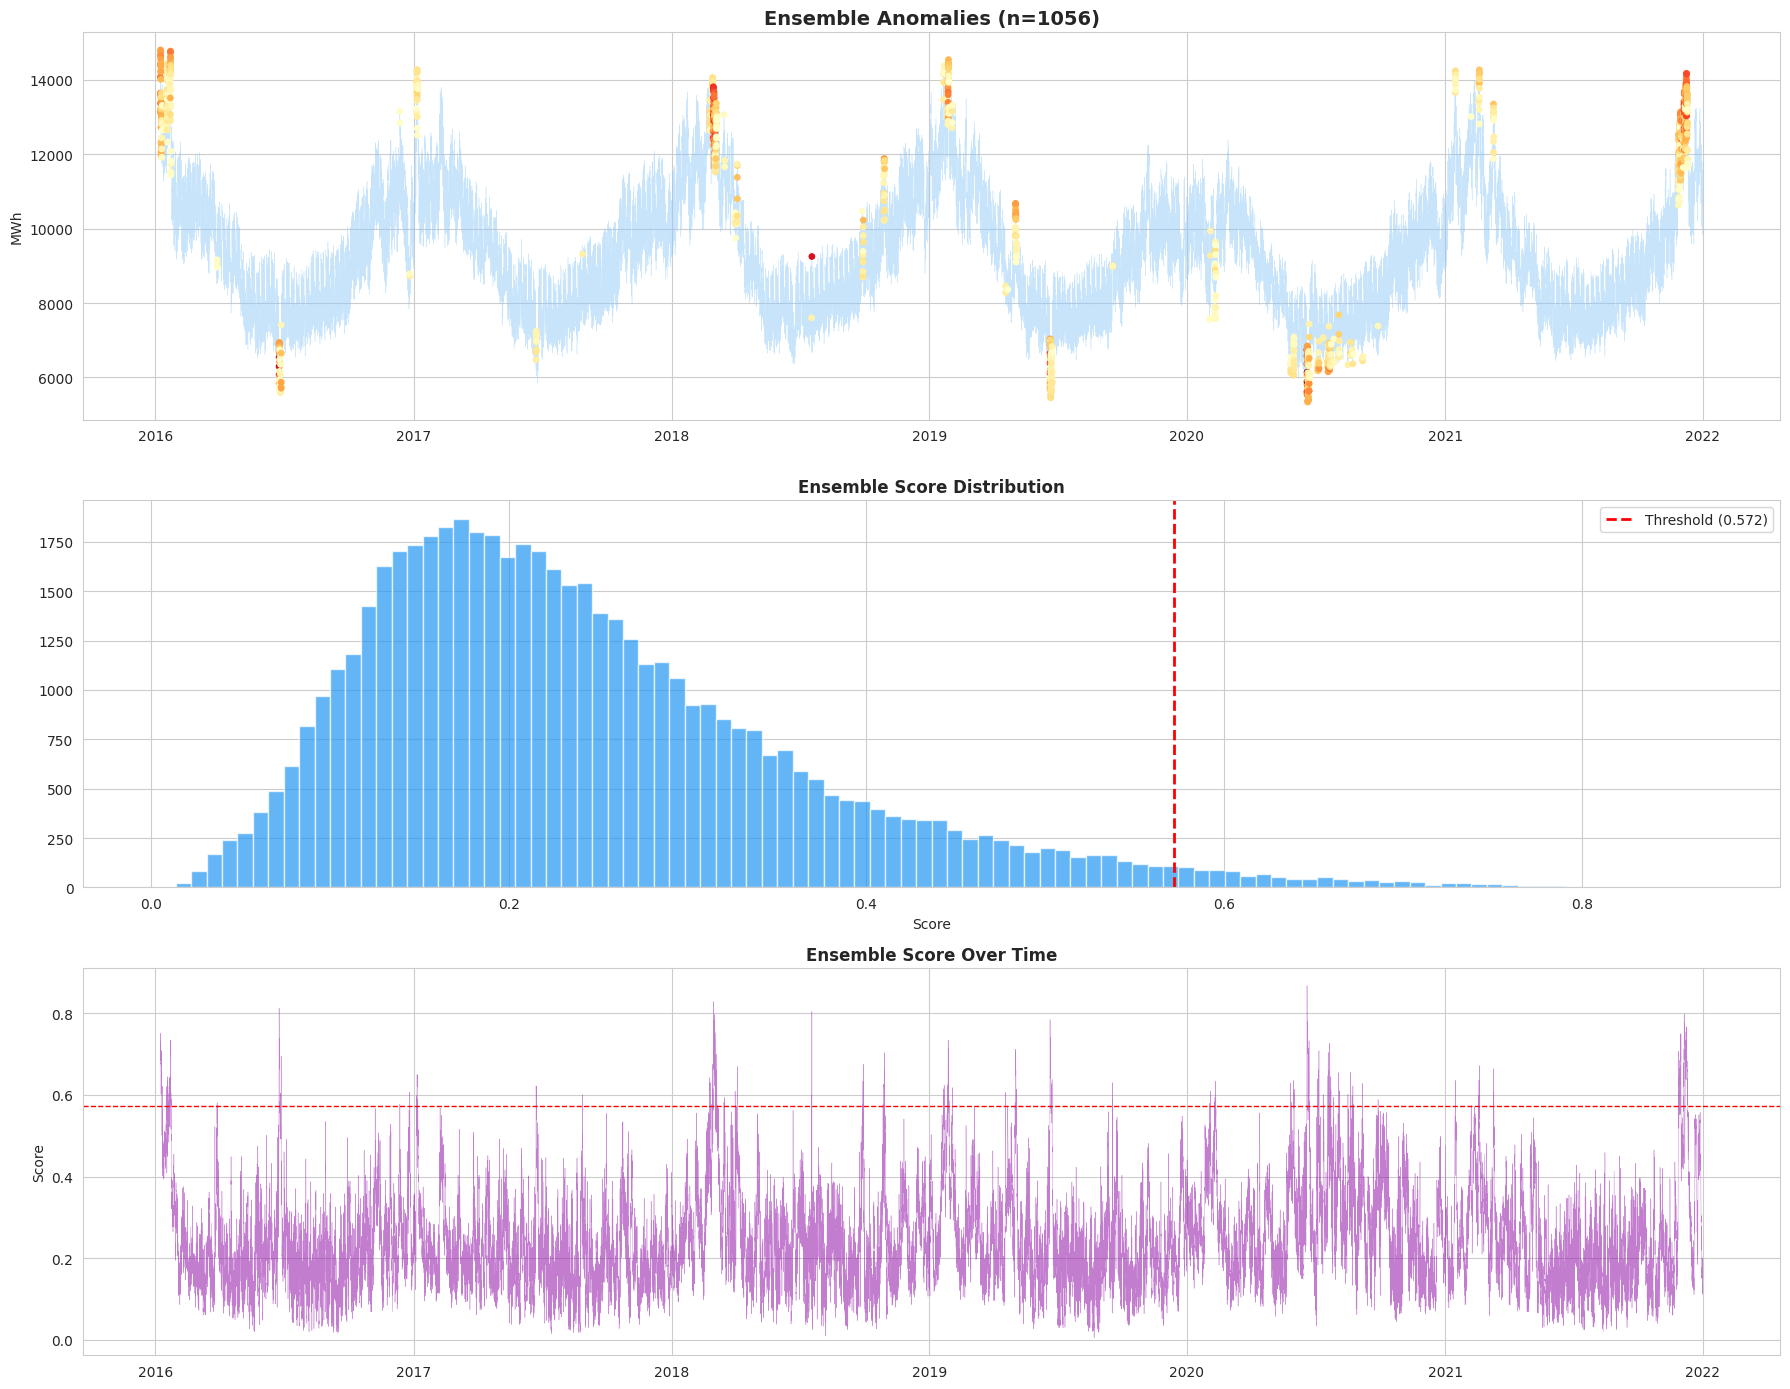

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

anoms = df_clean[df_clean['anom_ensemble'] == 1]

# Full series with anomalies
axes[0].plot(df_clean['start'], df_clean['consumption'], lw=0.3, alpha=0.5, color='#90CAF9')
axes[0].scatter(anoms['start'], anoms['consumption'], c=anoms['ensemble_score'],
               cmap='YlOrRd', s=15, zorder=5)
axes[0].set_title(f'Ensemble Anomalies (n={len(anoms)})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MWh')

# Score distribution
axes[1].hist(df_clean['ensemble_score'], bins=100, color='#2196F3', alpha=0.7, edgecolor='white')
axes[1].axvline(ensemble_thresh, color='red', linestyle='--', linewidth=2, label=f'Threshold ({ensemble_thresh:.3f})')
axes[1].set_title('Ensemble Score Distribution', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()

# Score over time
axes[2].plot(df_clean['start'], df_clean['ensemble_score'], lw=0.3, alpha=0.6, color='#9C27B0')
axes[2].axhline(ensemble_thresh, color='red', linestyle='--', linewidth=1)
axes[2].set_title('Ensemble Score Over Time', fontweight='bold')
axes[2].set_ylabel('Score')

plt.tight_layout()
plt.show()

## 5. Synthetic Anomaly Injection (Validation)
Since we have no labeled ground truth, we inject known anomalies and measure detection rate.

In [7]:
np.random.seed(42)

# Create a copy for injection
df_synth = df_clean.copy()
n_inject = 200
inject_idx = np.random.choice(df_synth.index, size=n_inject, replace=False)
df_synth['is_injected'] = 0
df_synth.loc[inject_idx, 'is_injected'] = 1

# Save original values
df_synth['original_consumption'] = df_synth['consumption']

# Inject different anomaly types
spike_idx = inject_idx[:80]   # 80 spikes
drop_idx = inject_idx[80:160]  # 80 drops
noise_idx = inject_idx[160:]   # 40 noise

# Spikes: multiply by 1.3-1.8
df_synth.loc[spike_idx, 'consumption'] = df_synth.loc[spike_idx, 'consumption'] * np.random.uniform(1.3, 1.8, len(spike_idx))

# Drops: multiply by 0.3-0.6
df_synth.loc[drop_idx, 'consumption'] = df_synth.loc[drop_idx, 'consumption'] * np.random.uniform(0.3, 0.6, len(drop_idx))

# Noise: add random large deviation
df_synth.loc[noise_idx, 'consumption'] = df_synth.loc[noise_idx, 'consumption'] + np.random.normal(0, 3000, len(noise_idx))

df_synth['inject_type'] = 'none'
df_synth.loc[spike_idx, 'inject_type'] = 'spike'
df_synth.loc[drop_idx, 'inject_type'] = 'drop'
df_synth.loc[noise_idx, 'inject_type'] = 'noise'

print(f"Injected {n_inject} synthetic anomalies:")
print(f"  Spikes: {len(spike_idx)}")
print(f"  Drops:  {len(drop_idx)}")
print(f"  Noise:  {len(noise_idx)}")
print(f"  Avg spike magnitude: {df_synth.loc[spike_idx, 'consumption'].mean():.0f} vs original {df_synth.loc[spike_idx, 'original_consumption'].mean():.0f}")
print(f"  Avg drop magnitude:  {df_synth.loc[drop_idx, 'consumption'].mean():.0f} vs original {df_synth.loc[drop_idx, 'original_consumption'].mean():.0f}")

Injected 200 synthetic anomalies:
  Spikes: 80
  Drops:  80
  Noise:  40
  Avg spike magnitude: 14446 vs original 9450
  Avg drop magnitude:  4425 vs original 9519


In [8]:
# Drop old context columns to avoid merge conflicts
for col in ['ctx_mean', 'ctx_std', 'ctx_zscore', 'ctx_zscore_abs']:
    if col in df_synth.columns:
        df_synth = df_synth.drop(columns=[col])

# Re-run Context-Aware on synthetic datadf_synth = context_aware_zscore(df_synth)df_synth['anom_ctx_synth'] = (df_synth['ctx_zscore_abs'] > ctx_threshold).astype(int)# Re-run Isolation Forest on synthetic datasynth_features = df_synth[feature_cols].valuessynth_scaled = scaler.transform(synth_features)df_synth['iso_pred_synth'] = iso_model.predict(synth_scaled)df_synth['iso_score_synth'] = iso_model.decision_function(synth_scaled)df_synth['anom_iso_synth'] = (df_synth['iso_pred_synth'] == -1).astype(int)# Ensemble on syntheticctx_s = df_synth['ctx_zscore_abs'].values.reshape(-1, 1)iso_s = -df_synth['iso_score_synth'].values.reshape(-1, 1)ctx_n = MinMaxScaler().fit_transform(ctx_s).flatten()iso_n = MinMaxScaler().fit_transform(iso_s).flatten()df_synth['ensemble_score_synth'] = w_ctx * ctx_n + w_iso * iso_ndf_synth['anom_ensemble_synth'] = (df_synth['ensemble_score_synth'] > np.percentile(df_synth['ensemble_score_synth'], ensemble_pct)).astype(int)# Detection ratesprint("=== Synthetic Anomaly Detection Rates ===")injected = df_synth[df_synth['is_injected'] == 1]for method, col in [('Context Z-Score', 'anom_ctx_synth'), ('Isolation Forest', 'anom_iso_synth'), ('Ensemble', 'anom_ensemble_synth')]:    detected = injected[col].sum()    rate = 100 * detected / len(injected)    print(f"  {method}: {detected}/{len(injected)} detected ({rate:.1f}%)")    for t in ['spike', 'drop', 'noise']:        sub = injected[injected['inject_type'] == t]        d = sub[col].sum()        r = 100 * d / len(sub)        print(f"    {t}: {d}/{len(sub)} ({r:.1f}%)")    print()# False positive rate (normal points flagged)normal = df_synth[df_synth['is_injected'] == 0]for method, col in [('Context Z-Score', 'anom_ctx_synth'), ('Isolation Forest', 'anom_iso_synth'), ('Ensemble', 'anom_ensemble_synth')]:    fp = normal[col].sum()    fpr = 100 * fp / len(normal)    print(f"  {method} FPR: {fp}/{len(normal)} ({fpr:.2f}%)")

## 6. Anomaly Classification
Classify detected anomalies into types: SPIKE, DROP, CONTEXTUAL, PATTERN_SHIFT

In [9]:
def classify_anomaly(row):
    """Classify anomaly type based on deviation characteristics."""
    consumption = row['consumption']
    ctx_mean = row['ctx_mean']
    rolling_mean_24 = row['rolling_mean_24']
    diff_24 = row['diff_24']
    
    # Percentage deviation from context mean
    ctx_dev = (consumption - ctx_mean) / ctx_mean * 100
    
    # Percentage deviation from rolling mean
    if pd.notna(rolling_mean_24) and rolling_mean_24 > 0:
        roll_dev = (consumption - rolling_mean_24) / rolling_mean_24 * 100
    else:
        roll_dev = 0
    
    # Classification logic
    if ctx_dev > 15:
        return 'SPIKE'
    elif ctx_dev < -15:
        return 'DROP'
    elif abs(ctx_dev) > 8:
        # Moderate deviation but contextually unusual
        return 'CONTEXTUAL'
    else:
        return 'PATTERN_SHIFT'

# Classify only ensemble anomalies
anomaly_mask = df_clean['anom_ensemble'] == 1
df_clean.loc[anomaly_mask, 'anomaly_type'] = df_clean[anomaly_mask].apply(classify_anomaly, axis=1)
df_clean.loc[~anomaly_mask, 'anomaly_type'] = 'NORMAL'

print("=== Anomaly Classification ===")
print(df_clean[df_clean['anom_ensemble']==1]['anomaly_type'].value_counts())

# Severity scoring
def severity_score(row):
    if row['anom_ensemble'] == 0:
        return 'NORMAL'
    score = row['ensemble_score']
    if score > np.percentile(df_clean['ensemble_score'], 99.5):
        return 'CRITICAL'
    elif score > np.percentile(df_clean['ensemble_score'], 99):
        return 'HIGH'
    elif score > np.percentile(df_clean['ensemble_score'], 98):
        return 'MEDIUM'
    else:
        return 'NORMAL'

df_clean['severity'] = df_clean.apply(severity_score, axis=1)
print("\n=== Severity Distribution ===")
print(df_clean[df_clean['severity']!='NORMAL']['severity'].value_counts())

=== Anomaly Classification ===
anomaly_type
SPIKE            635
CONTEXTUAL       234
DROP             171
PATTERN_SHIFT     16
Name: count, dtype: int64

=== Severity Distribution ===
severity
MEDIUM      528
CRITICAL    264
HIGH        264
Name: count, dtype: int64


## 7. Final Visualization

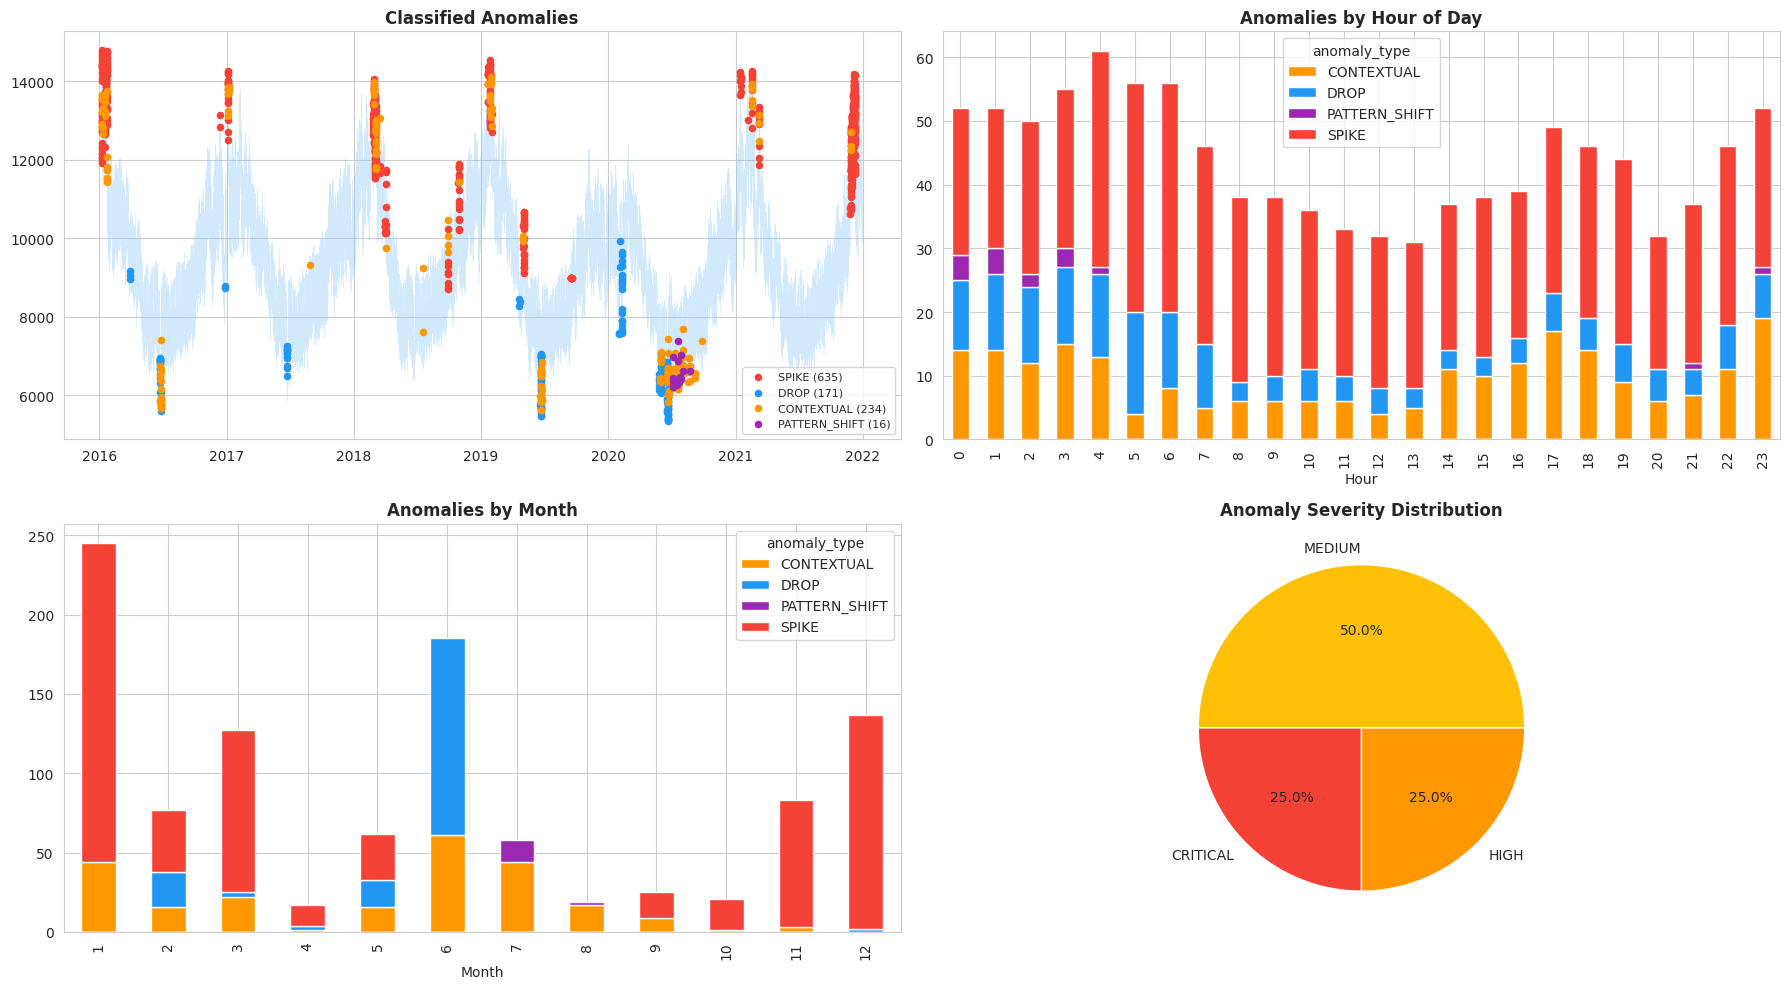

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

anoms = df_clean[df_clean['anom_ensemble'] == 1]

# Plot 1: Full series with classified anomalies
ax = axes[0, 0]
ax.plot(df_clean['start'], df_clean['consumption'], lw=0.3, alpha=0.4, color='#90CAF9')
colors_map = {'SPIKE': '#F44336', 'DROP': '#2196F3', 'CONTEXTUAL': '#FF9800', 'PATTERN_SHIFT': '#9C27B0'}
for atype, color in colors_map.items():
    sub = anoms[anoms['anomaly_type'] == atype]
    if len(sub) > 0:
        ax.scatter(sub['start'], sub['consumption'], c=color, s=20, label=f'{atype} ({len(sub)})', zorder=5)
ax.set_title('Classified Anomalies', fontweight='bold')
ax.legend(fontsize=8)

# Plot 2: Anomalies by hour
ax = axes[0, 1]
hour_counts = anoms.groupby(['hour', 'anomaly_type']).size().unstack(fill_value=0)
hour_counts.plot.bar(stacked=True, ax=ax, color=[colors_map.get(c, '#999') for c in hour_counts.columns])
ax.set_title('Anomalies by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour')

# Plot 3: Anomalies by month
ax = axes[1, 0]
month_counts = anoms.groupby(['month', 'anomaly_type']).size().unstack(fill_value=0)
month_counts.plot.bar(stacked=True, ax=ax, color=[colors_map.get(c, '#999') for c in month_counts.columns])
ax.set_title('Anomalies by Month', fontweight='bold')
ax.set_xlabel('Month')

# Plot 4: Severity pie chart
ax = axes[1, 1]
sev_data = df_clean[df_clean['severity']!='NORMAL']['severity'].value_counts()
sev_colors = {'CRITICAL': '#F44336', 'HIGH': '#FF9800', 'MEDIUM': '#FFC107'}
ax.pie(sev_data.values, labels=sev_data.index, autopct='%1.1f%%',
       colors=[sev_colors.get(s, '#999') for s in sev_data.index])
ax.set_title('Anomaly Severity Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Top Anomalies — Detailed Inspection

In [11]:
top_anomalies = df_clean[df_clean['anom_ensemble']==1].nlargest(20, 'ensemble_score')[
    ['start', 'consumption', 'hour', 'dow', 'month', 'is_weekend',
     'ctx_mean', 'ctx_zscore', 'ensemble_score', 'anomaly_type', 'severity']
].copy()

top_anomalies['ctx_deviation_%'] = ((top_anomalies['consumption'] - top_anomalies['ctx_mean']) / top_anomalies['ctx_mean'] * 100).round(1)

print("=== Top 20 Most Anomalous Points ===")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(top_anomalies.to_string(index=False))

=== Top 20 Most Anomalous Points ===
              start  consumption  hour  dow  month  is_weekend     ctx_mean  ctx_zscore  ensemble_score anomaly_type severity  ctx_deviation_%
2020-06-19 04:00:00         6139     4    4      6           0  8146.666667   -3.662554        0.867771         DROP CRITICAL            -24.6
2020-06-19 05:00:00         6366     5    4      6           0  8420.038760   -3.854415        0.856083         DROP CRITICAL            -24.4
2020-06-19 03:00:00         5889     3    4      6           0  7637.162791   -3.444439        0.846625         DROP CRITICAL            -22.9
2020-06-19 06:00:00         6578     6    4      6           0  8570.201550   -3.808693        0.833432         DROP CRITICAL            -23.2
2018-03-01 04:00:00        13782     4    3      3           0 10977.681481    3.148112        0.828765        SPIKE CRITICAL             25.5
2016-06-24 04:00:00         6296     4    4      6           0  8146.666667   -3.376141        0.812803  

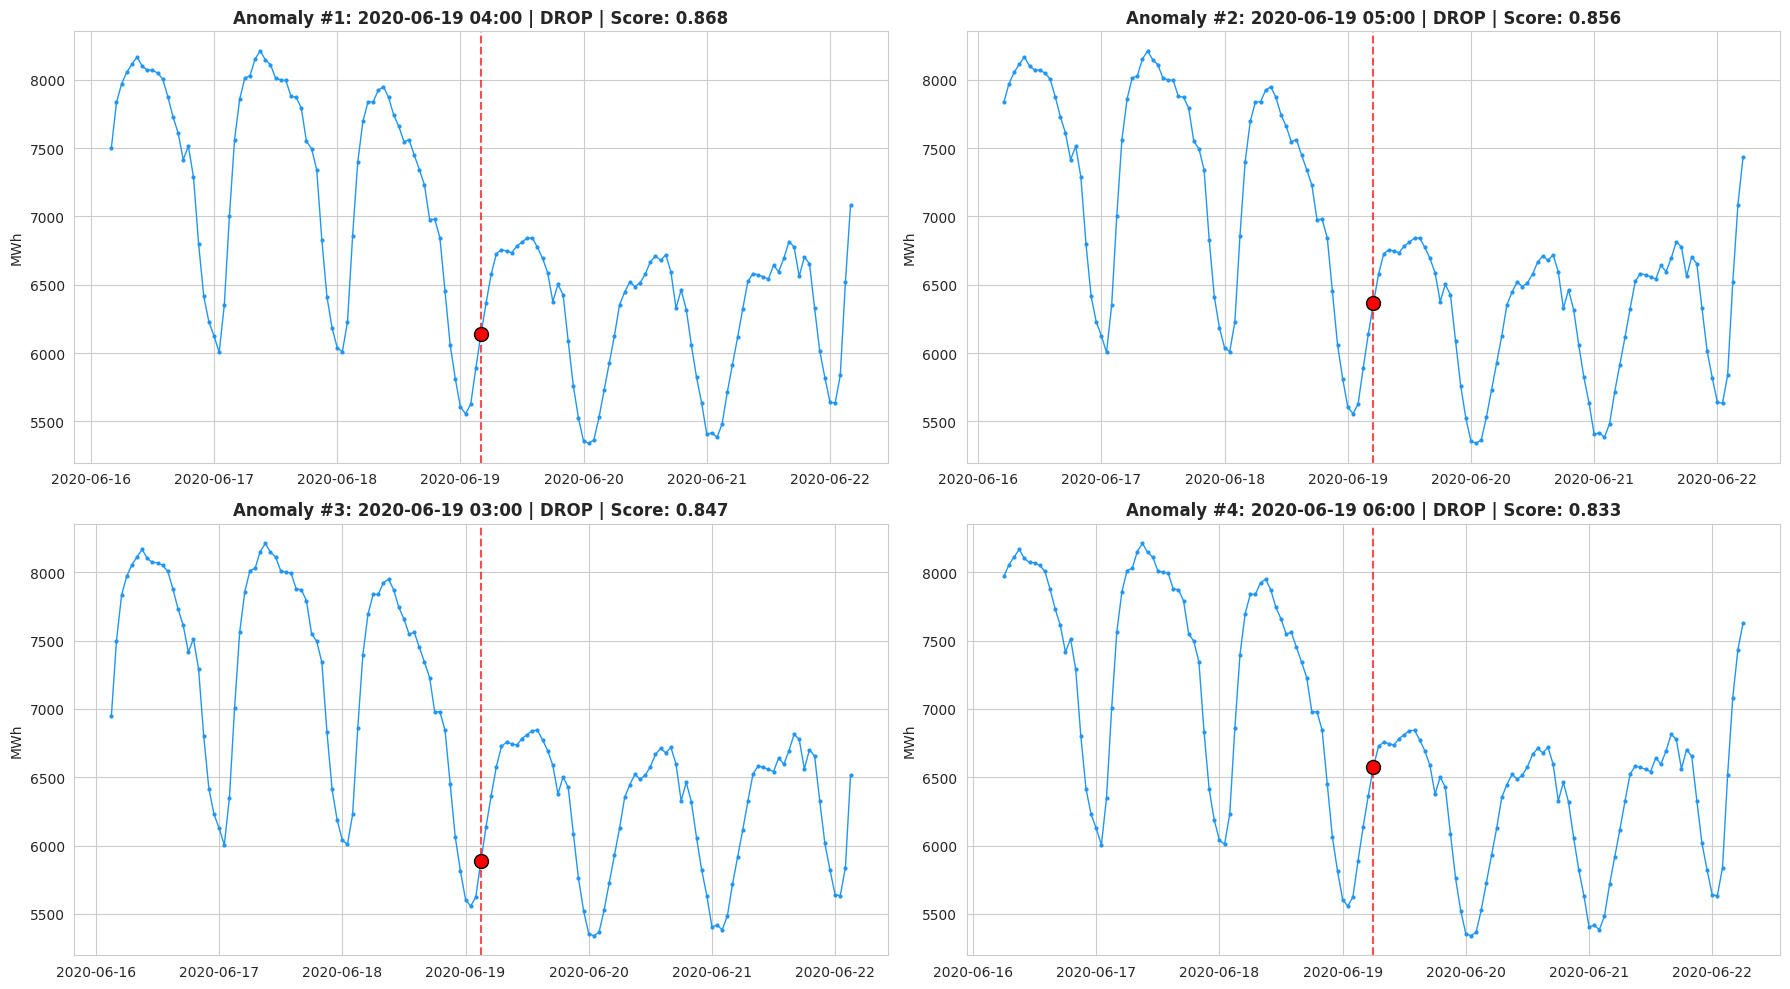

In [12]:
# Zoom into the neighborhood of top 4 anomalies
top4 = df_clean[df_clean['anom_ensemble']==1].nlargest(4, 'ensemble_score')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for idx, (ax, (_, row)) in enumerate(zip(axes.flat, top4.iterrows())):
    t = row['start']
    window = pd.Timedelta(days=3)
    mask = (df_clean['start'] >= t - window) & (df_clean['start'] <= t + window)
    local = df_clean[mask]
    
    ax.plot(local['start'], local['consumption'], 'o-', lw=1, ms=2, color='#2196F3')
    ax.axvline(t, color='red', linestyle='--', alpha=0.7)
    ax.scatter([t], [row['consumption']], c='red', s=100, zorder=5, edgecolors='black')
    ax.set_title(f"Anomaly #{idx+1}: {t.strftime('%Y-%m-%d %H:%M')} | {row['anomaly_type']} | Score: {row['ensemble_score']:.3f}", fontweight='bold')
    ax.set_ylabel('MWh')

plt.tight_layout()
plt.show()

## 9. Export Model & Results

In [13]:
import pickle

# Save the trained models and parameters
model_artifacts = {
    'iso_model': iso_model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'ctx_threshold': ctx_threshold,
    'ensemble_weights': {'ctx': w_ctx, 'iso': w_iso},
    'ensemble_threshold': ensemble_thresh,
    'ensemble_percentile': ensemble_pct,
    'iso_contamination': iso_cont,
}

with open('anomaly_models.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)
print("Models saved to anomaly_models.pkl")

# Save anomaly results
anomaly_results = df_clean[df_clean['anom_ensemble'] == 1][[
    'start', 'consumption', 'hour', 'dow', 'month', 'is_weekend',
    'ctx_mean', 'ctx_zscore', 'iso_score', 'ensemble_score',
    'anomaly_type', 'severity'
]].copy()
anomaly_results.to_csv('detected_anomalies.csv', index=False)
print(f"Anomaly results saved: {len(anomaly_results)} anomalies to detected_anomalies.csv")

# Save full scored dataset
df_clean.to_csv('scored_dataset.csv', index=False)
print(f"Full scored dataset saved: {len(df_clean)} rows to scored_dataset.csv")

Models saved to anomaly_models.pkl
Anomaly results saved: 1056 anomalies to detected_anomalies.csv
Full scored dataset saved: 52798 rows to scored_dataset.csv


## Summary

### Models Trained:
1. **Context-Aware Z-Score Detector** - Groups by (hour, weekend, month), flags |Z| > threshold
2. **Isolation Forest** - 200 estimators, 19 engineered features, tuned contamination
3. **Weighted Ensemble** - 60% context + 40% IF, percentile-based threshold

### Outputs:
- `anomaly_models.pkl` — Trained models for reuse/deployment
- `detected_anomalies.csv` — All detected anomalies with classification & severity
- `scored_dataset.csv` — Full dataset with all features and scores

### Next Steps:
- Build interactive dashboard (Plotly/Streamlit) for exploring anomalies
- Implement real-time simulation mode
- Connect to the forecasting model for predictive anomaly detection